In [1]:
import os
import re
import pandas as pd
import numpy as np
import pycountry
import geopandas as gpd
import gettext
import unicodedata
from babel import Locale
import japanize_matplotlib  # noqa: F401
import plotly.express as px
import nbformat

from collections import defaultdict

In [4]:
def _norm(s: str) -> str:
    # Normalize user input to reduce superficial mismatches (width, spaces, etc.)
    return unicodedata.normalize("NFKC", s).strip()


def build_japanese_country_index() -> dict[str, set[str]]:
    """
    Build a reverse index: Japanese country name -> set of ISO 3166-1 alpha-2 codes.
    The set is used to represent possible ambiguities.
    """
    index: dict[str, set[str]] = defaultdict(set)

    # 1) CLDR-based common display names
    loc = Locale.parse("ja")
    for code, name in loc.territories.items():
        if isinstance(code, str) and len(code) == 2 and code.isalpha():
            index[_norm(name)].add(code.upper())

    # 2) ISO-style official-ish names via pycountry gettext
    tr = gettext.translation(
        "iso3166-1", pycountry.LOCALES_DIR, languages=["ja"], fallback=True
    )
    _ = tr.gettext

    for c in pycountry.countries:
        for attr in ("name", "official_name", "common_name"):
            if hasattr(c, attr):
                jp_name = _(getattr(c, attr))
                index[_norm(jp_name)].add(c.alpha_2)
    return index


def jp_country_to_alpha2(jp_name: str, index: dict[str, set[str]]) -> str | None:
    """
    Resolve a Japanese country name to ISO alpha-2.
    Returns None when unknown or ambiguous.
    """
    codes = index.get(_norm(jp_name), set())
    if len(codes) == 1:
        return next(iter(codes))
    return None


def iso_a2_to_a3(alpha2: str | None) -> str | None:
    if alpha2 is None:
        return None
    
    # Normalize input (strip spaces and uppercase)
    code = alpha2.strip().upper()
    country = pycountry.countries.get(alpha_2=code)
    # Return ISO 3166-1 alpha-3 if found; otherwise None
    return country.alpha_3 if country is not None else None

idx = build_japanese_country_index()
print(jp_country_to_alpha2("韓国", idx))
print(jp_country_to_alpha2("大韓民国 (韓国)", idx))
print(iso_a2_to_a3("KR"))
print(iso_a2_to_a3("FR"))

KR
KR
KOR
FRA


In [5]:
# ---------- Load ----------
path = "海外在留邦人数調査統計（令和7年10月1日現在：機械判別用）.csv"  # or .xlsx

def load_table(path: str) -> pd.DataFrame:
    """Load CSV/XLSX robustly for Japanese datasets."""
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        # Try common encodings for Japanese CSV exports
        for enc in ("utf-8-sig", "cp932", "utf-8"):
            try:
                return pd.read_csv(path, encoding=enc)
            except UnicodeDecodeError:
                continue
        raise
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path)
    raise ValueError("Unsupported file type. Use .csv or .xlsx/.xls")

df0 = load_table(path)

# ---------- Normalize column names ----------
def normalize_colname(s: str) -> str:
    """Normalize Japanese column names by removing half/full-width spaces and trimming."""
    if not isinstance(s, str):
        return s
    s = s.replace("　", "")  # full-width space
    s = re.sub(r"\s+", "", s)  # any whitespace
    return s.strip()

df0.columns = [normalize_colname(c) for c in df0.columns]

# Expected normalized names after this step:
# 西暦（暦年）, 地域, 国（地域）名・在外公館名, 全体集計合計, ... , 長期滞在者合計, ... , 永住者合計, ... , 成人数
# Note: "地　域" becomes "地域"

# ---------- Select & coerce numeric columns ----------
COL_YEAR = "西暦（暦年）"
COL_REGION = "地域"
COL_NAME = "国（地域）名・在外公館名"

COL_TOTAL = "全体集計合計"
COL_LONG  = "長期滞在者合計"
COL_PERM  = "永住者合計"

use_cols = [COL_YEAR, COL_REGION, COL_NAME, COL_TOTAL, COL_LONG, COL_PERM]
missing = [c for c in use_cols if c not in df0.columns]
if missing:
    raise KeyError(f"Missing expected columns after normalization: {missing}")

df = df0[use_cols].copy()

def to_number(x):
    """Convert numbers that may include commas or non-numeric markers into floats."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # Remove commas and common placeholders
    s = s.replace(",", "")
    s = s.replace("－", "-")  # full-width dash
    # Drop non-numeric remnants
    return pd.to_numeric(s, errors="coerce")

df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce").astype("Int64")
for c in (COL_TOTAL, COL_LONG, COL_PERM):
    df[c] = df[c].apply(to_number)

# ---------- Optional: exclude overseas missions (embassy/consulate) ----------
# This is a heuristic. Adjust patterns to match your file’s conventions.
MISSION_PAT = re.compile(r"(大使館|総領事館|領事館|代表部|事務所|領事事務所|出張駐在官|在外公館)", re.UNICODE)

df["is_mission"] = df[COL_NAME].astype(str).apply(lambda s: bool(MISSION_PAT.search(s)))
df_country = (
    df.loc[~df["is_mission"]].copy()
    
)

# ---------- Reshape to long format ----------
df_long = df_country.melt(
    id_vars=[COL_YEAR, COL_REGION, COL_NAME],
    value_vars=[COL_TOTAL, COL_LONG, COL_PERM],
    var_name="metric_jp",
    value_name="count",
)

METRIC_MAP = {
    COL_TOTAL: "total",
    COL_LONG:  "long_term",
    COL_PERM:  "permanent",
}
df_long["metric"] = df_long["metric_jp"].map(METRIC_MAP)
df_long = df_long.rename(columns={
    COL_YEAR: "year",
    COL_REGION: "region",
    COL_NAME: "country_name",
})

# Minimal schema for mapping notebook:
df_stats = df_long[["region", "country_name", "metric", "count"]].copy()
df_stats = (
    df_stats.dropna(subset=["country_name"])
    .assign(
        ISO_A2=lambda d: d["country_name"].apply(jp_country_to_alpha2, args=(idx,)),
        ISO_A3=lambda d: d["ISO_A2"].apply(iso_a2_to_a3),
    )
)
df_stats


,region,country_name,metric,count,ISO_A2,ISO_A3
0,アジア,インド,total,8865,IN,IND
1,アジア,インドネシア,total,15266,ID,IDN
2,アジア,カンボジア,total,2915,KH,KHM
3,アジア,シンガポール,total,33397,SG,SGP
4,アジア,スリランカ,total,553,LK,LKA
...,...,...,...,...,...,...
637,アフリカ,リベリア,permanent,0,LR,LBR
638,アフリカ,ルワンダ,permanent,5,RW,RWA
639,アフリカ,レユニオン（仏領）,permanent,16,None,None
640,アフリカ,レソト,permanent,5,LS,LSO


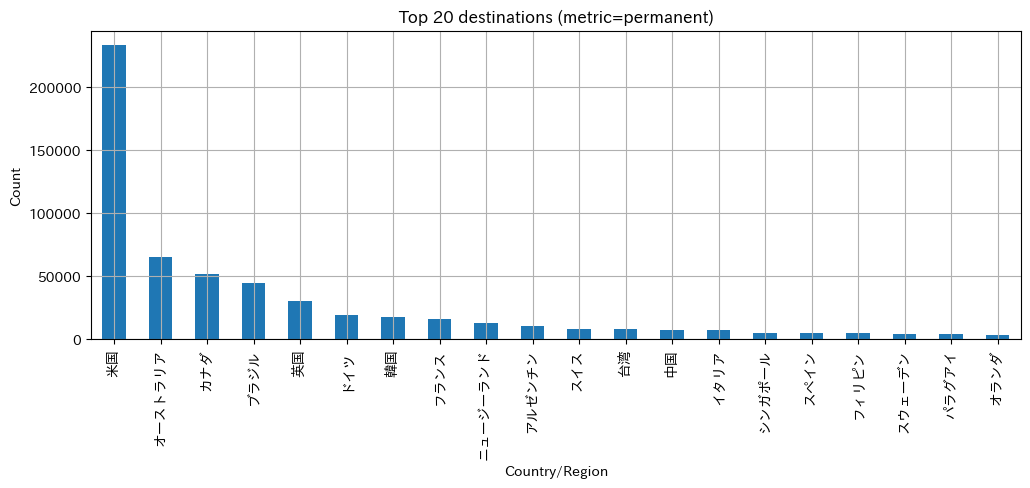

In [7]:
# Top-N bar chart
METRIC = "permanent"

top_n = 20
df_top = (
    df_stats.loc[df_stats["metric"] == METRIC].dropna(subset=["count"]).sort_values("count", ascending=False)
).head(top_n)

ax = df_top.plot(kind="bar", x="country_name", y="count", legend=False, figsize=(12, 4))
ax.set_xlabel("Country/Region")
ax.set_ylabel("Count")
ax.set_title(f"Top {top_n} destinations (metric={METRIC})")
ax.grid()

In [13]:
df_plot = df_stats.copy()

# Compute log10 only for positive counts; non-positive -> NaN (excluded from color)
df_plot["count_log10"] = np.log10(df_plot["count"].where(df_plot["count"] > 0))

fig = px.choropleth(
    df_plot,
    locations="ISO_A3",
    color="count_log10",
    hover_name="country_name",
    hover_data={
        "count": ":,d",
        "count_log10": ":.3f",
        "metric": True,
    },
    title=f"Overseas Japanese population (metric={METRIC})",
)

# Build log10 tick positions and label them as counts (10^x)
log_min = np.floor(df_plot["count_log10"].min())
log_max = np.ceil(df_plot["count_log10"].max())
tickvals = np.arange(log_min, log_max + 1, 1)
ticktext = [f"{int(10**v):,}" for v in tickvals]  # labels in original scale

fig.update_coloraxes(
    colorbar=dict(
        title="count (log10 color)",
        tickmode="array",
        tickvals=tickvals,
        ticktext=ticktext,
    )
)

fig.update_layout(
    autosize=True,
    margin=dict(l=0, r=0, t=40, b=0),
    title=dict(x=0.5, xanchor="center", y=0.98, yanchor="top"),
)

fig.show()
